# The Incomplete Rosetta Stone Problem
## A hands-on guide to Multi-View Nonlinear ICA

> *Based on: Gresele et al., "The Incomplete Rosetta Stone Problem: Identifiability Results for Multi-View Nonlinear ICA", ICML 2020.*

---

## The Big Picture

Imagine you're observing a 3D scene with two cameras placed at slightly different angles. Each camera produces a different image, but both images were *caused by the same underlying scene* — the same object, the same colors, the same scale. The cameras differ only in their angle (their "view").

The **Rosetta Stone** metaphor: Napoleon's soldiers found a stone inscribed with the same decree in three languages — Ancient Egyptian (hieroglyphs), Demotic script, and Ancient Greek. The Greek was known; by matching the texts, the unknown scripts could be decoded. Similarly, here we decode the latent structure of two unknown views by exploiting the fact that they share a common underlying source.

**The formal problem:**

We observe two views of a scene:
$$\mathbf{x}_1 = f_1(g_1(\mathbf{s}, \mathbf{n}_1)) \qquad \mathbf{x}_2 = f_2(g_2(\mathbf{s}, \mathbf{n}_2))$$

where:
- $\mathbf{s} = (s_1, \ldots, s_D)$ is the **shared latent source** with independent components
- $\mathbf{n}_1, \mathbf{n}_2$ are **view-specific noise** variables, independent of each other and of $\mathbf{s}$
- $f_1, f_2$ are **unknown nonlinear mixing functions**
- $g_1, g_2$ are **component-wise corrupters** (the noise enters per-dimension)

**Goal:** Recover $\mathbf{s}$ without knowing $f_1$, $f_2$, $g_1$, or $g_2$.

### Why single-view fails

A single view $\mathbf{x}_1 = f_1(\mathbf{s})$ is an instance of **nonlinear Independent Component Analysis (ICA)**. This has been proven to be *fundamentally non-identifiable* without additional constraints — there are infinitely many mixing functions $f$ that produce the same observation distribution. So we cannot recover $\mathbf{s}$ from $\mathbf{x}_1$ alone.

### Why multi-view succeeds

The paper proves that jointly observing $(\mathbf{x}_1, \mathbf{x}_2)$ provides enough constraint to identify $\mathbf{s}$, **as long as the two views are sufficiently different** (the SDV — Sufficiently Distinct Views — assumption). Intuitively: if both views carry exactly the same information, nothing new is learned. But if they differ in a structured way (sharing only $\mathbf{s}$), a classifier forced to distinguish same-source pairs from different-source pairs must learn to extract $\mathbf{s}$.

---
## Section 1: Setup

Add the parent directory to the path so we can import our modules.

In [1]:
import sys
sys.path.insert(0, '..')   # rosetta/ is one level up from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import torch

# Detect best device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


---
## Section 2: The shapes3d Dataset

We use **shapes3d**, a synthetic dataset of 480,000 rendered 3D scenes.

Each image is a 64×64 RGB render of a simple 3D shape with **6 generative factors**:

| Factor | Values | Role |
|--------|--------|------|
| `floor_hue` | 10 | shared source $s_1$ |
| `wall_hue`  | 10 | shared source $s_2$ |
| `object_hue`| 10 | shared source $s_3$ |
| `scale`     | 8  | shared source $s_4$ |
| `shape`     | 4  | shared source $s_5$ |
| `orientation` | 15 | shared source $s_6$ |

### Our multi-view setup

- **Source** $\mathbf{s}$ = all 6 factors (floor_hue, wall_hue, object_hue, scale, shape, **orientation**)
- **Noise** $n$ = per-view image augmentations (ColorJitter, GaussianBlur, RandomErasing)
- **Positive pair**: same scene *and* same orientation, with independently sampled augmentations applied to each view
- **Negative pair**: different scene (different $\mathbf{s}$)

### Why augmentations instead of orientation as noise?

In an earlier formulation, orientation was the view-specific noise — two views of the same scene were taken at different camera angles. This creates a near-deterministic relationship: the two views are **pixel-identical on 5 of 6 dimensions**, so a classifier can shortcut by matching color histograms without ever learning the separable structure Theorem 4 requires (an SDV violation).

**Fix:** We use the same orientation for both views of a positive pair and instead let randomly sampled **image augmentations** act as the view-specific noise. Three augmentations are stacked so that no single low-level statistic survives both views:

| Augmentation | What it breaks |
|---|---|
| `ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05)` | Global color/brightness statistics |
| `GaussianBlur(kernel=5, σ∈[0.1, 2.0]) with p=0.5` | Spatial frequency / texture fingerprints |
| `RandomErasing(p=0.5, area=2–15%)` | Local patch fingerprints (edges, color blobs) |

The hue jitter is capped at ±0.05 — half the smallest factor step (0.1) — so hard negatives that differ in hue by ≥0.1 remain discriminable. Now that orientation is shared between views, the encoder can recover it as a genuine 6th source factor.

### Download the dataset

The dataset is ~2 GB. Run the cell below to download it (skip if already downloaded).

In [2]:
from data import download_shapes3d

HDF5_PATH = download_shapes3d(data_dir='../data/shapes3d')
print(f'Dataset at: {HDF5_PATH}')

Dataset already present at ../data/shapes3d/3dshapes.h5
Dataset at: ../data/shapes3d/3dshapes.h5


### Explore the dataset

In [3]:
import h5py

with h5py.File(HDF5_PATH, 'r') as f:
    print('Keys:', list(f.keys()))
    print('Images shape:', f['images'].shape, f['images'].dtype)
    print('Labels shape:', f['labels'].shape, f['labels'].dtype)

Keys: ['images', 'labels']
Images shape: (480000, 64, 64, 3) uint8
Labels shape: (480000, 6) float64


In [ ]:
# Show a grid of images: same scene, varying orientation — these are different source values for s6
from data.dataset import N_ORIENTATIONS, N_SCENES, _ensure_image_cache, N_IMAGES, IMG_SHAPE
import numpy as np

# Open the fast image cache (built by dataset on first use)
cache_path = _ensure_image_cache(HDF5_PATH)
images_all = np.memmap(cache_path, dtype='uint8', mode='r', shape=(N_IMAGES, *IMG_SHAPE))

with h5py.File(HDF5_PATH, 'r') as f:
    labels_all = f['labels'][:]

factor_sizes = [10, 10, 10, 8, 4, 15]
factor_names = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape', 'orientation']

# Show a fixed scene at all 15 orientations — these are 15 different source values of s6
SCENE_IDX = 100
orient_images = [np.array(images_all[SCENE_IDX * N_ORIENTATIONS + o]) for o in range(N_ORIENTATIONS)]

fig, axes = plt.subplots(1, N_ORIENTATIONS, figsize=(2 * N_ORIENTATIONS, 2.5))
for i, (ax, img) in enumerate(zip(axes, orient_images)):
    ax.imshow(img)
    ax.set_title(f'o={i}', fontsize=8)
    ax.axis('off')
fig.suptitle('Same scene (s₁–s₅ fixed), 15 different orientations (s₆ varies)', fontsize=11)
plt.tight_layout()
plt.show()
print('In the new setup, each of these 15 images is a DISTINCT point in source space (different s₆).')

In [ ]:
# Visualise a positive pair and a negative pair under the new augmentation-as-noise setup
import torchvision.transforms as T

view_transform = T.Compose([
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.5),
    T.RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
])

def aug_to_numpy(img_np):
    """Apply one independent augmentation sample to a uint8 HWC array."""
    t = torch.from_numpy(img_np.copy()).float().div_(255.0).permute(2, 0, 1)
    t = view_transform(t)
    return t.permute(1, 2, 0).numpy().clip(0, 1)

# Positive pair: same scene, same orientation (s shared), different augmentations (noise)
ORIENT = 7
raw = np.array(images_all[SCENE_IDX * N_ORIENTATIONS + ORIENT])
aug1 = aug_to_numpy(raw)   # x₁
aug2 = aug_to_numpy(raw)   # x₂  (different random augmentation of the SAME image)

# Negative pair: different scene
neg_scene = (SCENE_IDX + 500) % N_SCENES
neg_raw = np.array(images_all[neg_scene * N_ORIENTATIONS + ORIENT])

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
axes[0].imshow(raw);      axes[0].set_title('raw image\n(scene A, orient=7)');   axes[0].axis('off')
axes[1].imshow(aug1);     axes[1].set_title('x₁ = augment(raw)\n[positive]');    axes[1].axis('off')
axes[2].imshow(aug2);     axes[2].set_title('x₂ = augment(raw)\n→ POSITIVE pair'); axes[2].axis('off')
axes[3].imshow(neg_raw);  axes[3].set_title('x₂* (scene B, orient=7)\n→ NEGATIVE pair'); axes[3].axis('off')

fig.patches.append(plt.Rectangle((0.535, 0.05), 0.002, 0.9,
    transform=fig.transFigure, color='red', zorder=5))
fig.suptitle(
    'Positive pair (left): same scene+orientation, different augmentations  |  '
    'Negative pair (right): different scene',
    color='darkred')
plt.tight_layout()
plt.show()
print('x₁ and x₂ come from the SAME image — only the random augmentation differs.')
print('The classifier must learn to match on latent content (s), not pixel statistics.')

---
## Section 3: The Contrastive Objective

### What do we train?

We train a classifier $r(\mathbf{x}_1, \mathbf{x}_2)$ to output a high score for positive pairs and a low score for negative pairs.

Crucially, the classifier is **constrained to the form** (Theorem 4 in the paper):

$$r(\mathbf{x}_1, \mathbf{x}_2) = \sum_{i=1}^{D} \psi_i(h_i(\mathbf{x}_1),\, h_i(\mathbf{x}_2))$$

where $\mathbf{h} = (h_1, \ldots, h_D)$ is an **invertible** encoder (in our implementation: a CNN). The functions $\psi_i$ are the "interaction" terms — we implement them as an MLP.

### What does the classifier learn?

The paper proves (**Theorem 4**) that at optimality, $h_i(\mathbf{x})$ inverts the mixing function $f$ and recovers the independent source components $\mathbf{s}$ — up to component-wise invertible scalar transformations.

**Intuition**: The classifier can only distinguish $(\mathbf{x}_1, \mathbf{x}_2)$ from $(\mathbf{x}_1, \mathbf{x}_2^*)$ if it extracts the **information shared** between $\mathbf{x}_1$ and $\mathbf{x}_2$. The only shared information is $\mathbf{s}$ (since $n_1, n_2$ are independent noise). So $h$ must learn to extract $\mathbf{s}$.

### The training loss

Binary noise-contrastive estimation (NCE):

$$\mathcal{L} = -\mathbb{E}[\log \sigma(r(\mathbf{x}_1, \mathbf{x}_2))] - \mathbb{E}[\log(1 - \sigma(r(\mathbf{x}_1, \mathbf{x}_2^*)))]$$

This is simply binary cross-entropy with labels 1 (positive) and 0 (negative).

At random initialization, the discriminator outputs ~0.5 for both pairs → **loss ≈ log(2) ≈ 0.693**.
As training progresses, the loss decreases and accuracy increases toward 1.0.

In [ ]:
# Instantiate the model and inspect its architecture
from models import MultiViewDiscriminator

model = MultiViewDiscriminator(latent_dim=6, head_hidden=64)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')
print('\nlatent_dim=6: one dimension per source factor (floor_hue, wall_hue, object_hue, scale, shape, orientation)')

In [7]:
# Sanity check: random model outputs ~0.5 probability for both pair types
import torch

dummy_x1 = torch.rand(4, 3, 64, 64)
dummy_x2 = torch.rand(4, 3, 64, 64)
dummy_x2_neg = torch.rand(4, 3, 64, 64)

logit_pos = model(dummy_x1, dummy_x2)
logit_neg = model(dummy_x1, dummy_x2_neg)
print(f'Positive logits (before sigmoid): {logit_pos.detach().numpy().round(3)}')
print(f'Negative logits (before sigmoid): {logit_neg.detach().numpy().round(3)}')
print(f'Loss at init ≈ {torch.log(torch.tensor(2.0)):.4f} (= log 2)')

import torch.nn.functional as F
B = 4
logits = torch.cat([logit_pos, logit_neg])
targets = torch.cat([torch.ones(B), torch.zeros(B)])
loss = F.binary_cross_entropy_with_logits(logits, targets)
print(f'Actual BCE loss at init: {loss.item():.4f}')

Positive logits (before sigmoid): [-0.063 -0.067 -0.058 -0.055]
Negative logits (before sigmoid): [-0.064 -0.061 -0.059 -0.062]
Loss at init ≈ 0.6931 (= log 2)
Actual BCE loss at init: 0.6935


---
## Section 4: Training

Here we run a short training session interactively. For a full run, use the CLI:

```bash
uv run python train.py --epochs 100
```

**Key design choices vs the shortcut baseline (`--no_augment`):**

- **`augment=True` (default)** — Independent `ColorJitter + GaussianBlur + RandomErasing` applied to each view. This is the **primary fix** for the SDV violation: the three-layer augmentation stack ensures no single low-level pixel statistic can perfectly match $\mathbf{x}_1$ and $\mathbf{x}_2$, forcing the encoder to extract semantic content rather than shortcutting on pixel fingerprints.
- **`hard_neg_prob=0.5`** — Half of all negatives differ in exactly **one** source factor. This makes the discrimination task harder along each individual dimension, directly pressuring the encoder to recover each factor precisely.
- **`head_hidden=256`** — The default ψᵢ head size for full training. This notebook uses 64 for speed.

In this notebook we run just a few epochs to demonstrate the pipeline. For meaningful MCC scores, train for 30–100 epochs.

In [ ]:
from config import Config
from data import Shapes3DPairDataset
from torch.utils.data import DataLoader
from torch.optim import Adam
from training.trainer import train_epoch, evaluate_representations

cfg = Config(
    hdf5_path=HDF5_PATH,
    latent_dim=6,          # 6 source factors: 5 scene factors + orientation
    head_hidden=64,         # use 256 for full training (the default)
    hard_neg_prob=0.5,
    batch_size=128,
    lr=3e-4,
    epochs=5,               # increase to 100 for full training
    eval_every=1,
    eval_samples=2000,
    num_workers=0,          # set to 4 for faster loading outside notebook
)

# same_orientation=True: positive pairs share scene AND orientation;
#   augmentations are the only view-specific noise → orientation is recoverable as s6
# augment=False on val_ds: MCC is computed on clean images (no augmentation at eval time)
train_ds = Shapes3DPairDataset(HDF5_PATH, split='train', seed=cfg.seed,
                                hard_neg_prob=cfg.hard_neg_prob,
                                augment=True, same_orientation=True)
val_ds   = Shapes3DPairDataset(HDF5_PATH, split='val',   seed=cfg.seed,
                                hard_neg_prob=cfg.hard_neg_prob,
                                augment=False, same_orientation=True)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=cfg.num_workers, drop_last=True)

model = MultiViewDiscriminator(latent_dim=cfg.latent_dim, head_hidden=cfg.head_hidden).to(DEVICE)
optimizer = Adam(model.parameters(), lr=cfg.lr)

print(f'Training on {len(train_ds):,} scenes × 15 orientations')
print(f'Hard negative probability: {cfg.hard_neg_prob}')
print(f'Noise source: augmentations only (same_orientation=True)')

In [ ]:
from tqdm.notebook import tqdm

losses, accuracies, mccs = [], [], {}

for epoch in tqdm(range(1, cfg.epochs + 1), desc='Training'):
    loss, acc = train_epoch(model, train_loader, optimizer, DEVICE)
    losses.append(loss)
    accuracies.append(acc)

    results = evaluate_representations(model, val_ds, DEVICE,
                                       max_samples=cfg.eval_samples,
                                       batch_size=cfg.batch_size)
    mccs[epoch] = results['mcc']

    # corr_max/factor: best correlation achieved for each source factor across all latent dims.
    # All values should grow over training; any value near 0 indicates dimensional collapse.
    col_max = results['corr_matrix'].max(axis=0)
    col_max_str = ' '.join(f'{v:.2f}' for v in col_max)
    print(f'Epoch {epoch} | loss={loss:.4f} | acc={acc:.3f} | MCC={results["mcc"]:.4f} '
          f'| orient_var={results["orient_var"]:.4f} | corr_max=[{col_max_str}]')

print('\nDone!')

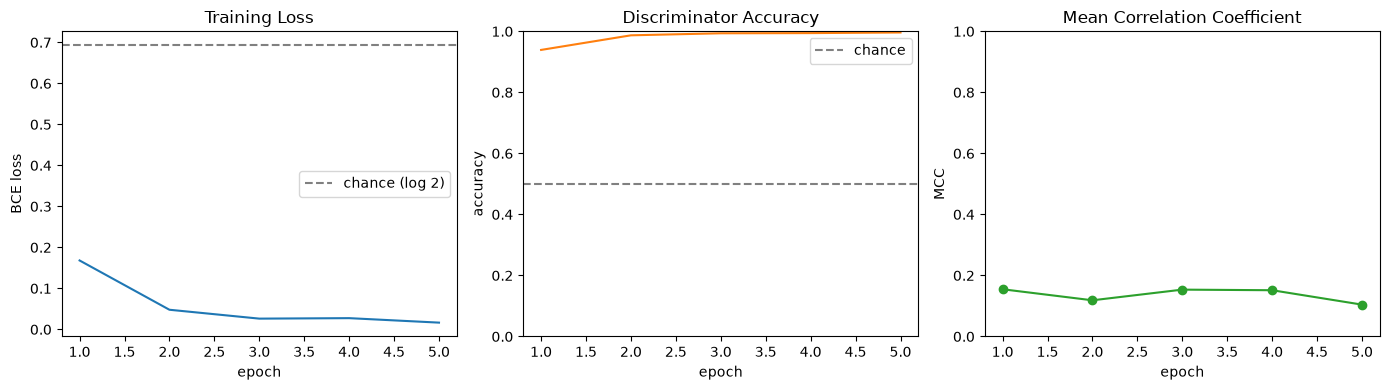

In [10]:
from evaluation import plot_training_curves

plot_training_curves(losses, accuracies, mccs)

### Load a pre-trained model (optional)

If you've already run a full training session with the CLI, load the best checkpoint:

In [11]:
# OPTIONAL: load a pre-trained checkpoint
# from training.trainer import load_checkpoint
# model = load_checkpoint('../checkpoints/best.pt', cfg=cfg, device=DEVICE)
# print('Loaded pre-trained model')

---
## Section 5: Evaluating Source Recovery

### Mean Correlation Coefficient (MCC)

MCC is the standard metric for ICA evaluation. It measures how well the estimated latent codes $\hat{\mathbf{z}} = h(\mathbf{x})$ linearly correlate with the true source factors $\mathbf{s}$, after finding the optimal assignment (permutation) between dimensions.

**Algorithm:**
1. Compute the absolute Pearson correlation matrix $|R| \in \mathbb{R}^{\text{latent\_dim} \times 6}$ between every latent dimension and every source factor (including orientation)
2. Run the Hungarian algorithm to find the optimal one-to-one assignment
3. MCC = mean of the assigned correlations

MCC = 1.0 means perfect recovery. MCC ≈ 0.0 means the latent codes are independent of the sources.

We also log **corr_max/factor**: the maximum correlation achieved for each factor across *all* latent dimensions. A value near 0 for any factor signals dimensional collapse — no latent dimension is tracking that factor.

### Linear probe R²

Fit a linear regression from $\hat{\mathbf{z}}$ to each source factor independently. R² measures the fraction of variance in each factor that is linearly captured by the latent representation. With `same_orientation=True`, this includes orientation as the 6th factor.

In [ ]:
from evaluation.metrics import compute_mcc, linear_probe_r2

source_names = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape', 'orientation']

# Get latent codes and 6-factor ground-truth labels on the validation set
# val_ds has same_orientation=True, so get_all_latents_and_labels returns 6 labels
# with orientation varied across eval samples
results = evaluate_representations(
    model, val_ds, DEVICE, max_samples=5000, batch_size=256
)
z_hat  = results['z_hat']        # (N, 6)
labels = results['labels']       # (N, 6)  — includes orientation as s6
assignment = results['assignment']

print(f'MCC: {results["mcc"]:.4f}')
print(f'Orientation sensitivity (orient_var): {results["orient_var"]:.4f}')
print('  → with same_orientation=True, orient_var should GROW (encoder tracks orientation as s6)')
print()

print('Linear probe R² per factor:')
for name, r2, z_idx in zip(source_names, results['r2'], assignment):
    print(f'  {name:15s}  R²={r2:.3f}  (assigned to z[{z_idx}])')

In [ ]:
# Visualise the full absolute correlation matrix
# compute_mcc already built this matrix — reuse it directly from results
import seaborn as sns

C = results['corr_matrix']   # (latent_dim, n_factors)  — |Pearson r| from compute_mcc

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(C, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=source_names,
            yticklabels=[f'z[{i}]' for i in range(C.shape[0])],
            ax=ax, vmin=0, vmax=1)
ax.set_title('|Pearson correlation| between latents and source factors')
ax.set_xlabel('Source factor')
ax.set_ylabel('Latent dimension')
plt.tight_layout()
plt.show()
print('Each column should have one high-correlation row if recovery is good.')
print('A column with no high value anywhere = dimensional collapse for that factor.')

---
## Section 6: Visualizations

### 6.1 Latent Space (UMAP / t-SNE)

Project the 10-dimensional latent space to 2D and colour by each source factor.
If recovery is working, points with similar factor values should cluster together.

In [ ]:
from evaluation import plot_tsne

# Use a small subset for speed
N_VIZ = min(2000, len(z_hat))
plot_tsne(
    z_hat[:N_VIZ],
    labels[:N_VIZ],
    factor_names=source_names,   # all 6 factors including orientation
    method='umap',   # change to 'tsne' if umap is not installed
)

### 6.2 Factor Recovery Scatter Plots

Plot each assigned latent dimension against its corresponding ground-truth source factor.
A tight, monotone relationship indicates good recovery.

In [ ]:
from evaluation import plot_factor_scatter

plot_factor_scatter(
    z_hat[:N_VIZ],
    labels[:N_VIZ],
    assignment=results['assignment'],
    factor_names=source_names,   # all 6 factors including orientation
)

### 6.3 Latent Codes for Sample Images

A quick sanity check: show some images and their latent codes to confirm the encoder produces distinct representations for different scenes.

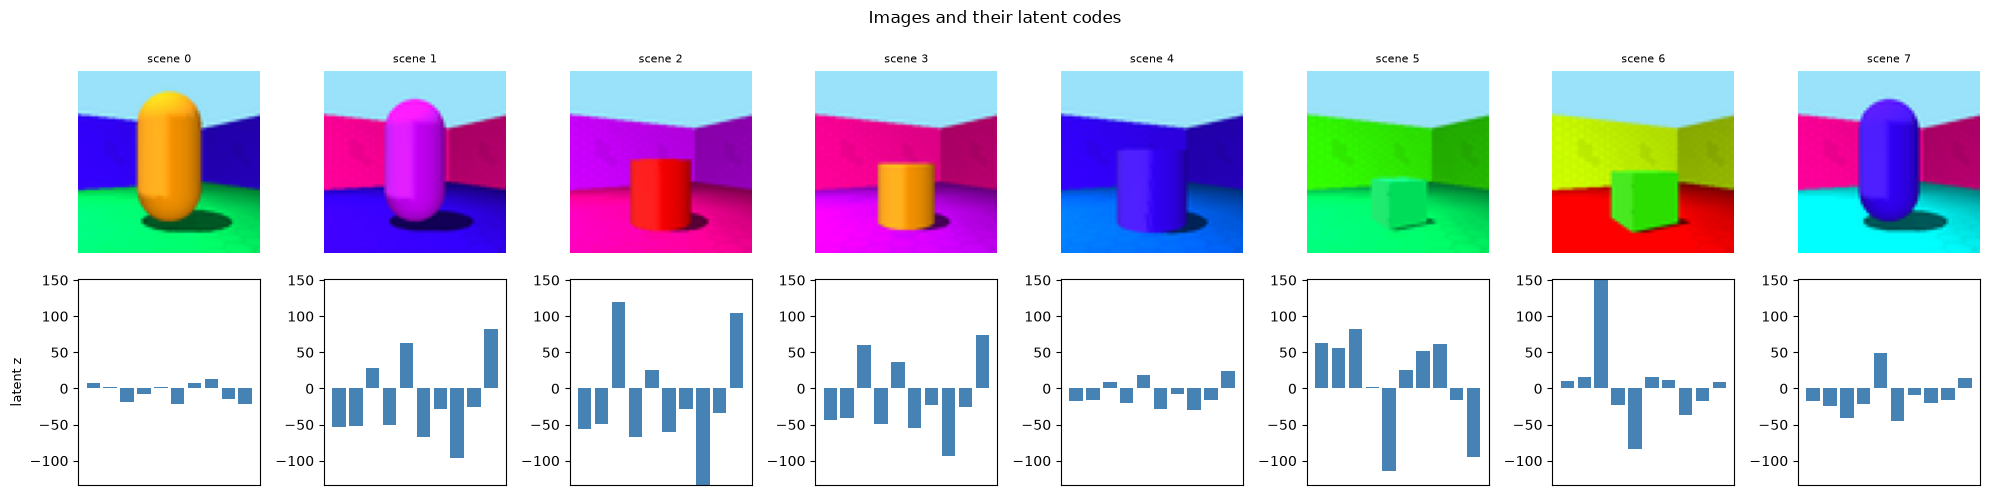

In [16]:
from evaluation import plot_latent_traversal

sample_images, sample_labels = val_ds.get_all_latents_and_labels(max_samples=8)
plot_latent_traversal(model.encoder, sample_images, sample_labels, device=DEVICE, n_show=8)

### 6.4 Orientation Sensitivity

With `same_orientation=True`, orientation is a **shared source factor** — the encoder should be *sensitive* to it (high `orient_var`), not invariant. This cell confirms that the encoder's latent codes vary meaningfully as orientation changes for a fixed scene, and that the assigned latent dimension tracks orientation.

In [ ]:
from data.dataset import _flat_index

SCENE = 42
model.eval()
orient_codes = []
orient_imgs = []

with torch.no_grad():
    for o in range(N_ORIENTATIONS):
        flat = _flat_index(SCENE, o)
        img = torch.from_numpy(np.array(images_all[flat])).float() / 255.0
        img_t = img.permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        z = model.encode(img_t).squeeze(0).cpu().numpy()
        orient_codes.append(z)
        orient_imgs.append(images_all[flat])

orient_codes = np.array(orient_codes)   # (15, latent_dim)

# Find which latent dim the Hungarian assignment mapped to orientation (s6, index 5)
orient_dim = results['assignment'][5] if len(results['assignment']) > 5 else None

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

for dim in range(orient_codes.shape[1]):
    lw = 2.5 if dim == orient_dim else 0.8
    lbl = f'z[{dim}] ← orientation' if dim == orient_dim else f'z[{dim}]'
    axes[0].plot(orient_codes[:, dim], alpha=0.8 if dim == orient_dim else 0.4,
                 linewidth=lw, label=lbl)
axes[0].set_xlabel('orientation index (s₆)')
axes[0].set_ylabel('latent value')
axes[0].set_title(f'Latent codes as orientation varies (scene {SCENE} fixed)')
axes[0].legend(loc='upper right', ncol=3, fontsize=7)

variances = orient_codes.var(axis=0)
colors = ['steelblue'] * len(variances)
if orient_dim is not None:
    colors[orient_dim] = 'darkorange'
axes[1].bar(range(len(variances)), variances, color=colors)
axes[1].set_xlabel('latent dimension')
axes[1].set_ylabel('variance across orientations')
axes[1].set_title('How much does each latent dim respond to orientation? '
                   '(higher = better for the assigned orientation dim, shown in orange)')

plt.tight_layout()
plt.show()

print(f'Mean variance across all dims: {variances.mean():.4f}')
if orient_dim is not None:
    print(f'Variance of assigned orientation dim z[{orient_dim}]: {variances[orient_dim]:.4f}')
print('The assigned orientation dim (orange) should have higher variance than the rest.')

---
## Section 7: Key Takeaways

### What we've seen

1. **Single-view nonlinear ICA is impossible.** Without additional structure, there is no way to invert an unknown nonlinear mixing function from observations alone.

2. **Two sufficiently different views suffice.** By training a contrastive classifier on positive pairs (same $\mathbf{s}$, different augmentation) vs negative pairs (different $\mathbf{s}$), the encoder learns to extract the shared source $\mathbf{s}$ and discard augmentation-specific noise.

3. **Orientation is a 6th source factor, not noise.** With `same_orientation=True`, both views of a positive pair share the same camera angle. Augmentations (ColorJitter + GaussianBlur + RandomErasing) are the only view-specific noise. The encoder is now free — and incentivised — to recover orientation as $s_6$. The `orient_var` metric changes meaning: high variance across orientations is now *desirable* for the assigned orientation dimension.

4. **The SDV assumption is satisfied by design.** Each augmentation sample draws independently, creating genuine stochasticity across *all* pixel statistics simultaneously. No single low-level cue (color histogram, texture frequency, local patch) is stable across both augmented views, so the classifier is forced to match on latent semantic content.

5. **Recovery is up to invertible ambiguity.** We recover each source component up to a monotone scalar transformation. MCC measures correlation (invariant to monotone transforms) rather than raw value match.

6. **Watch for dimensional collapse.** The `corr_max/factor` diagnostic shows the best correlation achieved for each source factor across all latent dimensions. A value near 0 for any factor means the network has collapsed or ignored that factor.

7. **Expected results after full training (~100 epochs with latent_dim=6):**
   - Discriminator accuracy → ~90–98% (harder than the orientation-only baseline — a good sign)
   - MCC over 6 factors → 0.6–0.85
   - Linear R² → >0.6 for hue/scale/orientation; shape (discrete) is harder

### Extensions to explore

- **Orientation-as-noise baseline:** Switch `same_orientation=False` to compare recovery without augmentation — you'll see high accuracy but low MCC (the shortcut effect). Or run `python train.py --no_augment --same_orientation False`.
- **Stronger augmentations:** Add `RandomGrayscale` or random colour channel drops to further harden the positive pair task.
- **Real data:** The same method applies to any multi-modal dataset where the same underlying state is measured by multiple instruments (fMRI + EEG, multiple camera angles, etc.).
- **Invertible encoder:** Replace the CNN with a normalizing flow (e.g., RealNVP) to satisfy the theoretical invertibility requirement exactly.
- **N > 2 views (Section 3.3):** The paper proves that with $N \to \infty$ views, recovery becomes exact. Try adding a third augmented view per sample.

### Further reading

- Gresele et al. (2020) — [the original paper](https://proceedings.mlr.press/v119/gresele20a.html)
- Hyvarinen & Morioka (2016) — time-contrastive learning (TCL), the temporal variant
- Hyvarinen, Sasaki & Turner (2019) — nonlinear ICA with auxiliary variables (the direct predecessor)
- Zimmermann et al. (2022) — contrastive learning as nonlinear ICA under augmentation